In [23]:
import xarray as xr
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.io.shapereader

In [24]:
os.makedirs("figures/RPSS drivers", exist_ok=True)

In [25]:
preds_unet = xr.open_dataarray('outputs/Full Period/GEFS_IMD/unet_predictions_wk3-4.nc')
obs_unet = xr.open_dataarray('outputs/Full Period/GEFS_IMD/unet_ytest_raw_wk3-4.nc')
obs_ohe = xr.open_dataarray('outputs/Full Period/GEFS_IMD/unet_y_test_wk3-4.nc')

preds_elr = xr.open_dataarray('outputs/Full Period/GEFS_IMD/ELR_predictions_wk3-4.nc')


# obs_unet has dims (bootstrap, T, Y, X)
valid_T_idx_per_bootstrap = {}

for b in obs_unet.bootstrap.values:
    # Select the bootstrap
    da = obs_unet.sel(bootstrap=b)
    
    # Boolean: True if the entire (Y,X) slice is NOT all NaN
    valid_times = ~da.isnull().all(dim=("Y", "X"))
    
    # Store the T coordinates where it is True
    valid_T_idx_per_bootstrap[b] = da['T'][valid_times].values


preds_list = []
obs_list = []
for b in range(len(obs_unet.bootstrap)):
    valid_T = valid_T_idx_per_bootstrap[b]  # datetime array
    # select bootstrap b
    da = preds_unet.sel(bootstrap=b)
    da_2 = obs_ohe.sel(bootstrap=b)
    # replace T for this bootstrap
    da = da.assign_coords(T=valid_T)
    da_2 = da_2.assign_coords(T=valid_T)
    obs_list.append(da_2)
    preds_list.append(da)

# concatenate along bootstrap again
preds_unet_final = xr.concat(preds_list, dim="bootstrap")
obs_ohe_final = xr.concat(obs_list, dim="bootstrap")

#check that the T coords match obs_unet
for b in range(len(obs_unet.bootstrap)):
    assert np.array_equal(
        preds_unet_final.sel(bootstrap=b)['T'].values,
        obs_unet.sel(bootstrap=b)['T'].values
    )

obs_unetM = obs_unet.mean(dim='bootstrap')
preds_unetM = preds_unet_final.mean(dim='bootstrap')
obs_oheM = obs_ohe_final.mean(dim='bootstrap')

#remove when all X Y is nan for a T
valid_times_unetM = ~obs_unetM.isnull().all(dim=("Y", "X"))
obs_unetM = obs_unetM.sel(T=obs_unetM['T'][valid_times_unetM])
preds_unetM = preds_unetM.sel(T=preds_unetM['T'][valid_times_unetM])
obs_oheM = obs_oheM.sel(T=obs_oheM['T'][valid_times_unetM])

In [26]:
def compute_rps(forecast, obs):
    """
    forecast: xarray.DataArray (..., category) probabilities, sum to 1 over category
    obs: xarray.DataArray (..., category) one-hot observations
    returns: xarray.DataArray of RPS over the last 'category' dim
    """
    # compute cumulative sums over category
    fc_cdf = forecast.cumsum(dim="category")
    obs_cdf = obs.cumsum(dim="category")
    
    # squared difference and sum over category
    rps = ((fc_cdf - obs_cdf) ** 2).sum(dim="category")
    
    return rps

climo_cat = xr.DataArray(
    np.ones(3) / 3,
    dims=["category"],
    coords={"category": preds_unetM["category"]}
)

# Broadcast to full (T, Y, X, category)
climo_probs = climo_cat.broadcast_like(preds_unetM)
rps = compute_rps(preds_unetM, obs_oheM)  # dims: (T,Y,X) or (bootstrap,T,Y,X)
rps_climo = compute_rps(climo_probs, obs_oheM)  # dims: (T,Y,X)
rpss = 1 - (rps / rps_climo)

#change T to 00:00:00 for matching with sst_anom
rpss = rpss.assign_coords(T=rps['T'].dt.floor('D'))
#mask with land mask
land_mask = preds_elr.isel(bootstrap=0,category=0).isnull().all(dim='T')
rpss = rpss.where(~land_mask)

In [27]:
rpss_mean = rpss.mean(dim='T')

# MJO

In [28]:

mjo = pd.read_csv(
    "download/mjo.txt",
    skiprows=2,
    delim_whitespace=True,
    header=None,
    names=["year","month","day","RMM1","RMM2","phase","amplitude","method", "extra"],
    na_values=[1e35, 999]
)

# drop the extra column (sometimes leftover from comments)
mjo = mjo.drop(columns="extra", errors="ignore")

# create datetime index
mjo["date"] = pd.to_datetime(
    dict(year=mjo.year, month=mjo.month, day=mjo.day),
    errors="coerce"
)

#filter to get 1980-2025
mjo = mjo[(mjo['date'] >= '1980-01-01') & (mjo['date'] <= '2025-12-31')]


C:\Users\emile\AppData\Local\Temp\ipykernel_10168\1887441726.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  mjo = pd.read_csv(


In [29]:
mjo['date'] = pd.to_datetime(mjo['date'])
mjo = mjo.set_index('date')
df_mjo_roll = mjo[['RMM1', 'RMM2']].rolling(window=15, center=True, min_periods=1).mean()
mjo_xr = df_mjo_roll[['RMM1', 'RMM2']].to_xarray()



rpss_dates = pd.to_datetime(rpss['T'].values)  # rps.T must be datetime64
rmm1_vals = mjo_xr['RMM1'].sel(date=rpss_dates, method='nearest')
rmm2_vals = mjo_xr['RMM2'].sel(date=rpss_dates, method='nearest')


# Create 1D DataArrays with T dimension
rmm1_da = xr.DataArray(rmm1_vals.values, dims=('T'), coords={'T': rpss['T']})
rmm2_da = xr.DataArray(rmm2_vals.values, dims=('T'), coords={'T': rpss['T']})

# Broadcast over (Y, X) of rps
rmm1_xr, _ = xr.broadcast(rmm1_da, rpss)
rmm2_xr, _ = xr.broadcast(rmm2_da, rpss)


rpss_ds = xr.Dataset({
    'RPSS': rpss,
    'RMM1': rmm1_xr,
    'RMM2': rmm2_xr,
    'Amplitude': np.sqrt(rmm1_xr**2 + rmm2_xr**2),
    'Phase': xr.DataArray(np.arctan2(rmm2_xr, rmm1_xr), dims=rpss.dims, coords=rpss.coords)
})

#add X and Y from obs_unetM
rpss_ds = rpss_ds.assign_coords({'X': obs_unetM['X'], 'Y': obs_unetM['Y']})

phase_1d = xr.DataArray(
    (((np.arctan2(rmm2_da, rmm1_da) + 2 * np.pi) % (2 * np.pi)) // (np.pi / 4) + 1).astype(int),
    dims=("T",),
    coords={"T": rpss["T"]},
    name="Phase_num"
)
rpss_ds = rpss_ds.assign(Phase_num=phase_1d)


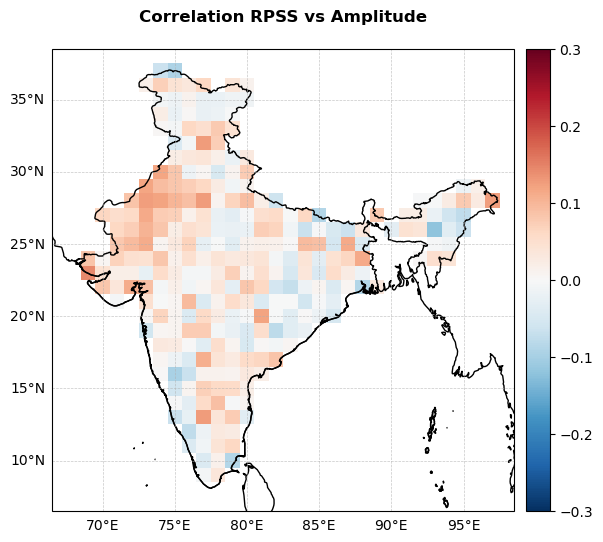

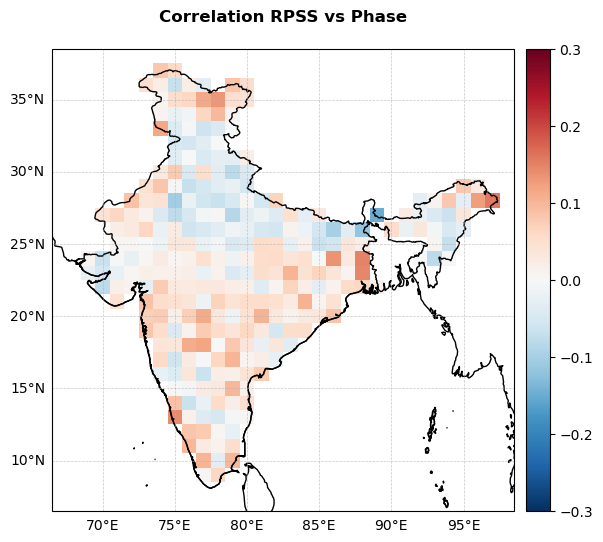

In [30]:
# Example plotting function using your style
def plot_map(da, model_name="", cmap="RdBu_r", vmin=-0.3, vmax=0.3):


    fig, ax = plt.subplots(figsize=(8,6), subplot_kw={'projection': ccrs.PlateCarree()})


    # Plot the data
    im = da.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    # Add coastlines
    ax.coastlines()

    # Add shapefiles
    for shape_name in ['indian_borders']:
        reader = cartopy.io.shapereader.Reader(f'shapes/{shape_name}.shp')
        ax.add_geometries(reader.geometries(), ccrs.PlateCarree(), facecolor='none', edgecolor='black')

    # Subplot title
    ax.set_title(f"{model_name}", fontsize=12, fontweight="bold", pad=20)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, alpha=0.7)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    # Colorbar
    cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02, fraction=0.05)

    plt.show()

# -------------------------------
# Plot correlations using the function
# -------------------------------
corr_amplitude = xr.corr(rpss_ds['RPSS'], rpss_ds['Amplitude'], dim='T')
corr_phase = xr.corr(rpss_ds['RPSS'], rpss_ds['Phase'], dim='T')

plot_map(corr_amplitude, model_name="Correlation RPSS vs Amplitude")
plot_map(corr_phase, model_name="Correlation RPSS vs Phase")


In [31]:

rpss_phase_map = (
    rpss_ds["RPSS"]
    .groupby(rpss_ds["Phase_num"])
    .mean(dim="T", skipna=True)
)


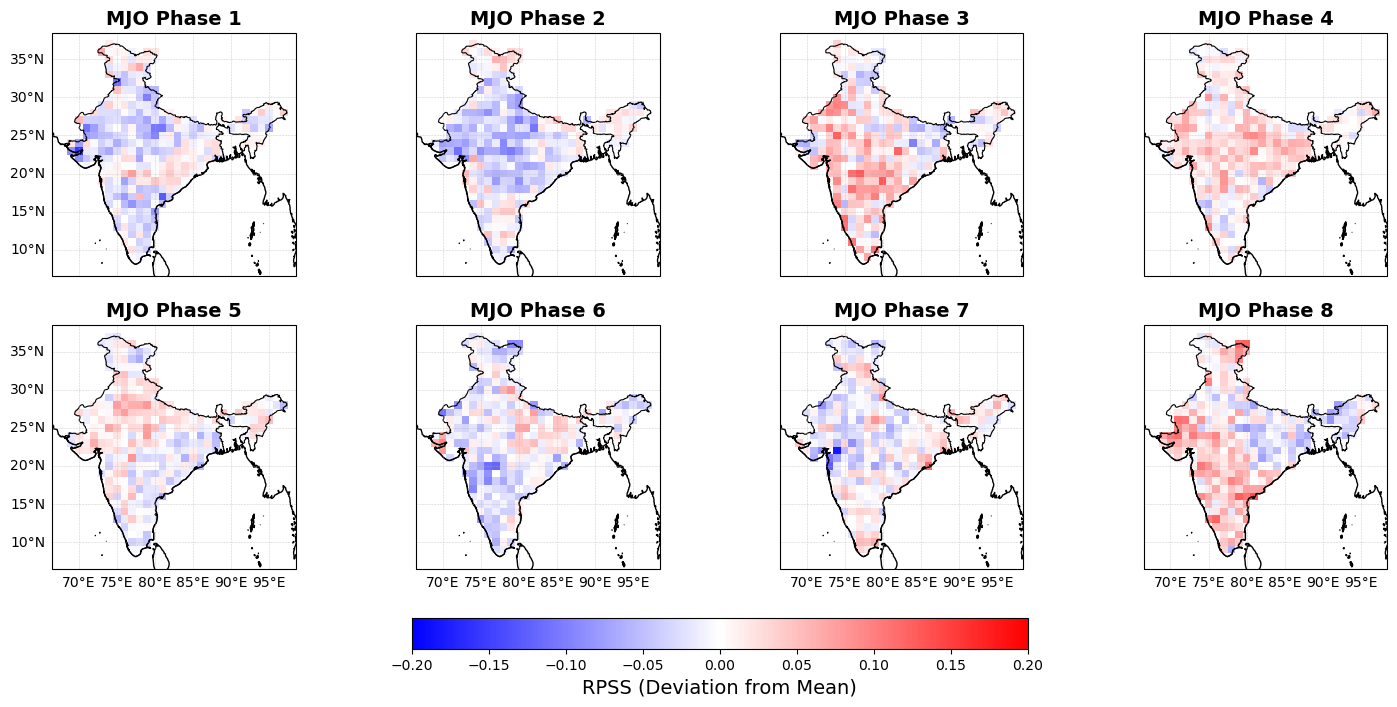

In [32]:
def plot_mjo_phases_2x4(
    rps_phase_map,
    demean=True,
    rpss_mean=rpss_mean,
    vmin=-0.2,
    vmax=0.2,
    cmap="bwr",
    suptitle="Mean RPSS conditioned on MJO Phase"
):

    fig, axes = plt.subplots(
        nrows=2,
        ncols=4,
        figsize=(18, 8),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    axes = axes.flatten()
    mappable = None   # <- store the plotted object for colorbar

    for i, phase in enumerate(range(1, 9)):
        ax = axes[i]

        rps = rps_phase_map.sel(Phase_num=phase)

        if demean:
            rps = rps - rpss_mean
        
        im = rps.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            add_colorbar=False
        )

        # save first (or last) mappable for colorbar
        if mappable is None:
            mappable = im

        # Coastlines
        ax.coastlines()

        # Shapefiles
        for shape_name in ["indian_borders"]:
            reader = cartopy.io.shapereader.Reader(f"shapes/{shape_name}.shp")
            ax.add_geometries(
                reader.geometries(),
                ccrs.PlateCarree(),
                facecolor="none",
                edgecolor="black",
                linewidth=0.8
            )

        # Titles
        ax.set_title(f"MJO Phase {phase}", fontsize=14, fontweight="bold", pad=6)

        # Gridlines with selective labels
        gl = ax.gridlines(
            draw_labels=True,
            linestyle="--",
            linewidth=0.4,
            alpha=0.6
        )

        gl.top_labels = False
        gl.right_labels = False

        if i % 4 != 0:
            gl.left_labels = False

        if i < 4:
            gl.bottom_labels = False

        gl.xlabel_style = {"size": 10}
        gl.ylabel_style = {"size": 10}

    # ------------------
    # Shared horizontal colorbar (FIXED)
    # ------------------
    cbar = fig.colorbar(
        mappable,
        ax=axes,
        orientation="horizontal",
        fraction=0.05,
        pad=0.08
    )
    cbar.set_label("RPSS (Deviation from Mean)", fontsize=14)

    # fig.suptitle(suptitle, fontsize=14, fontweight="bold", y=0.97)
    plt.savefig("figures/RPSS drivers/RPSS_MJO_phases.pdf", dpi=300, bbox_inches="tight")

    plt.show()
plot_mjo_phases_2x4(rpss_phase_map, vmin=-0.2, vmax=0.2)


# ENSO

In [33]:
import pandas as pd
import re

records = []

pattern = re.compile(r"[+-]?\d+\.\d+")

with open("download/sst_weekly.txt") as f:
    for line in f:
        if re.match(r"\s*\d{2}[A-Z]{3}\d{4}", line):
            date = line.split()[0]
            nums = list(map(float, pattern.findall(line)))

            if len(nums) == 8:  # expected SST/SSTA × 4 regions
                records.append([date] + nums)

cols = [
    "Week",
    "Nino12_SST", "Nino12_SSTA",
    "Nino3_SST", "Nino3_SSTA",
    "Nino34_SST", "Nino34_SSTA",
    "Nino4_SST", "Nino4_SSTA",
]

df = pd.DataFrame(records, columns=cols)
df["Week"] = pd.to_datetime(df["Week"], format="%d%b%Y")

nino = df.set_index("Week")

In [34]:
df_nino_2w = (
    nino
    .rolling(window=2, center=True, min_periods=1)
    .mean())

nino_xr = df_nino_2w.to_xarray()
# Broadcast over (Y, X) of rpss
rpss_dates = pd.to_datetime(rpss['T'].values)

nino_sel = nino_xr[["Nino4_SSTA", "Nino34_SSTA"]].sel(
    Week=rpss_dates,
    method="nearest"
)

# Rename + put on T dimension
nino_sel = nino_sel.rename({
    "Week": "T",
    "Nino4_SSTA": "nino4",
    "Nino34_SSTA": "nino34"
})

nino_sel = nino_sel.assign_coords(T=rpss_ds["T"])

nino_bc, _ = xr.broadcast(nino_sel, rpss_ds)

rpss_ds = rpss_ds.assign(
    nino4  = nino_bc["nino4"],
    nino34 = nino_bc["nino34"]
)

enso34_mode = xr.where(
    rpss_ds["nino34"].isel(Y=0, X=0) >=  0.5,  1,
    xr.where(
        rpss_ds["nino34"].isel(Y=0, X=0) <= -0.5, -1, 0
    )
)

enso4_mode = xr.where(
    rpss_ds["nino4"].isel(Y=0, X=0) >=  0.5,  1,
    xr.where(
        rpss_ds["nino4"].isel(Y=0, X=0) <= -0.5, -1, 0
    )
)

rpss_ds = rpss_ds.assign(ENSO34_mode=enso34_mode)
rpss_ds = rpss_ds.assign(ENSO4_mode=enso4_mode)


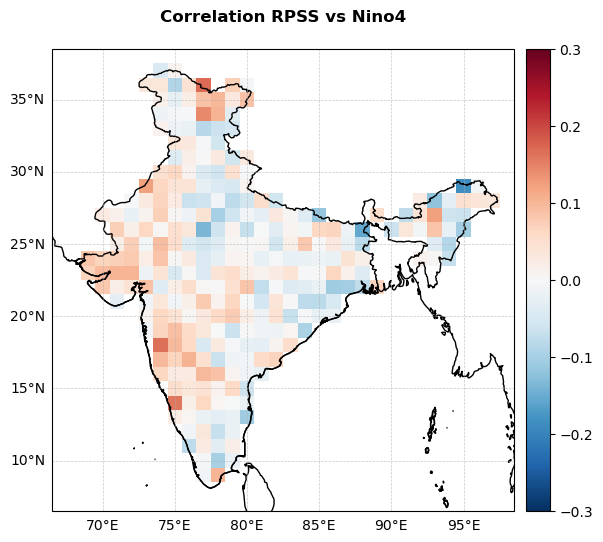

In [35]:
corr_nino = xr.corr(rpss_ds['RPSS'], rpss_ds['nino4'], dim='T')


plot_map(corr_nino, model_name="Correlation RPSS vs Nino4")

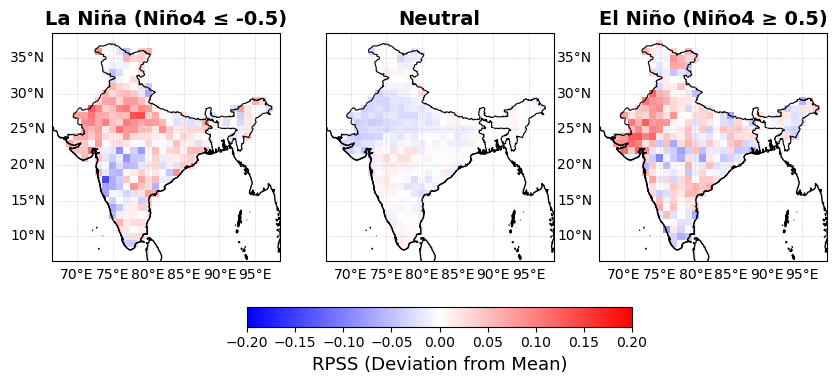

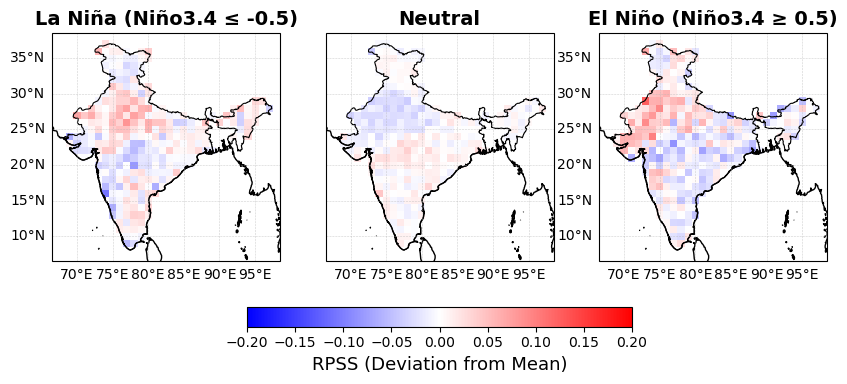

In [39]:
def plot_enso_mode(
    rpss_ds,
    mode="34",          # "34" or "4"
    vmin=-0.2,
    vmax=0.2,
    cmap="bwr",
    demean=True,
    rpss_mean=rpss_mean
):

    # ----------------------------------
    # Select which ENSO mode to use
    # ----------------------------------
    if mode == "34":
        enso_var = "ENSO34_mode"
        nino_label = "Niño3.4"
    elif mode == "4":
        enso_var = "ENSO4_mode"
        nino_label = "Niño4"
    else:
        raise ValueError("mode must be '34' or '4'")

    # ----------------------------------
    # Compute conditioned mean map
    # ----------------------------------
    rps_enso_map = (
        rpss_ds["RPSS"]
        .groupby(rpss_ds[enso_var])
        .mean(dim="T", skipna=True)
    )

    # ----------------------------------
    # Figure
    # ----------------------------------
    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(10, 5),
        subplot_kw={"projection": ccrs.PlateCarree()}
    )

    mappable = None   # for shared colorbar

    for i, enso in enumerate([-1, 0, 1]):
        ax = axes[i]

        rps = rps_enso_map.sel({enso_var: enso})

        # -------- demean if requested --------
        if demean:
            rps = rps - rpss_mean

        im = rps.plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            add_colorbar=False
        )

        # save first mappable for colorbar
        if mappable is None:
            mappable = im

        # Coastlines
        ax.coastlines()

        # Shapefiles
        for shape_name in ["indian_borders"]:
            reader = cartopy.io.shapereader.Reader(f"shapes/{shape_name}.shp")
            ax.add_geometries(
                reader.geometries(),
                ccrs.PlateCarree(),
                facecolor="none",
                edgecolor="black",
                linewidth=0.8
            )

        # Titles
        if enso == 1:
            title = f"El Niño ({nino_label} ≥ 0.5)"
        elif enso == -1:
            title = f"La Niña ({nino_label} ≤ -0.5)"
        else:
            title = "Neutral"

        ax.set_title(title, fontsize=14, fontweight="bold", pad=6)

        # Gridlines
        gl = ax.gridlines(
            draw_labels=True,
            linestyle="--",
            linewidth=0.4,
            alpha=0.6
        )

        gl.top_labels = False
        gl.right_labels = False
        if i == 1:
            gl.left_labels = False

        gl.xlabel_style = {"size": 10}
        gl.ylabel_style = {"size": 10}

    # ----------------------------------
    # Shared colorbar (FIXED + consistent)
    # ----------------------------------
    cbar = fig.colorbar(
        mappable,
        ax=axes,
        orientation="horizontal",
        fraction=0.05,
        pad=0.12
    )
    cbar.set_label("RPSS (Deviation from Mean)", fontsize=13)

    plt.savefig(f"figures/RPSS drivers/RPSS_ENSO_{mode}.pdf", dpi=300, bbox_inches="tight")
    plt.show()


plot_enso_mode(rpss_ds, mode="4", vmin=-0.2, vmax=0.2)
plot_enso_mode(rpss_ds, mode="34", vmin=-0.2, vmax=0.2)

In [37]:

rpss_enso_map = (
    rpss_ds["RPSS"]
    .groupby(rpss_ds["ENSO4_mode"])
    .mean(dim="T", skipna=True)
)

# demean
rpss_enso_map = rpss_enso_map - rpss_mean

df_enso = (
    rpss_enso_map
    .to_dataframe(name="RPSS")
    .reset_index()
    .dropna(subset=["RPSS"])
)

df_enso["Condition"] = "ENSO"
df_enso["Category"] = df_enso["ENSO4_mode"].map(
    {0: "Neutral", 1: "El Niño", -1: "La Niña"}
)


rpss_phase_map = (
    rpss_ds["RPSS"]
    .groupby(rpss_ds["Phase_num"])
    .mean(dim="T", skipna=True)
)

# demean
rpss_phase_map = rpss_phase_map - rpss_mean

df_mjo = (
    rpss_phase_map
    .to_dataframe(name="RPSS")
    .reset_index()
    .dropna(subset=["RPSS"])
)

df_mjo["Condition"] = "MJO"
df_mjo["Category"] = "P" + df_mjo["Phase_num"].astype(int).astype(str)

# ----------------------------------
# Combine (optional, but kept)
# ----------------------------------
df_all = pd.concat(
    [df_enso[["RPSS", "Condition", "Category"]],
     df_mjo[["RPSS", "Condition", "Category"]]],
    ignore_index=True
)


C:\Users\emile\AppData\Local\Temp\ipykernel_10168\93220614.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\emile\AppData\Local\Temp\ipykernel_10168\93220614.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\emile\AppData\Local\Temp\ipykernel_10168\93220614.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1200x500 with 0 Axes>

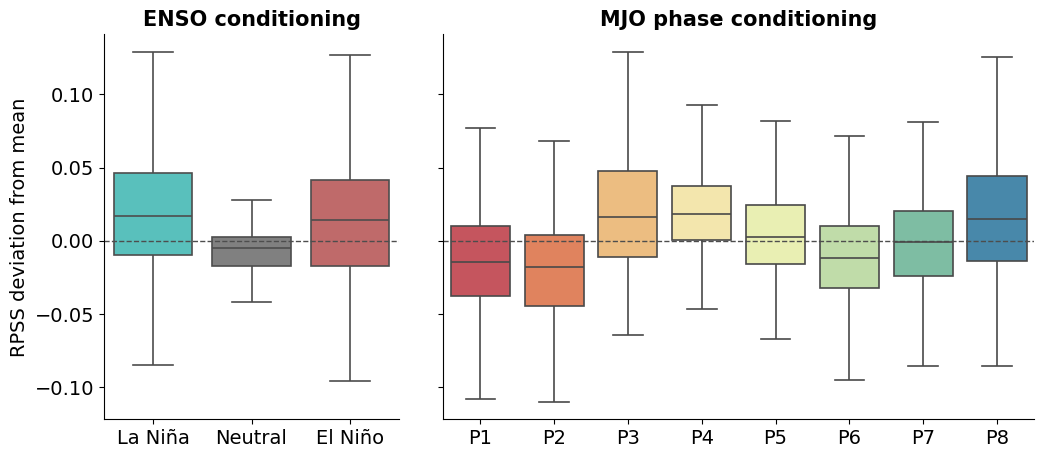

In [38]:


enso_palette = ['mediumturquoise','gray','indianred']  # La Niña, Neutral, El Niño
mjo_palette  = sns.color_palette("Spectral", 8)  # modern, perceptually uniform


plt.figure(figsize=(12, 5))

fig, axes = plt.subplots(
    ncols=2,
    figsize=(12, 5),
    sharey=True,
    gridspec_kw={"width_ratios": [1, 2], "wspace": 0.1}
)

# ------------------
# ENSO panel
# ------------------
sns.boxplot(
    data=df_enso,
    x="Category",
    y="RPSS",
    palette=enso_palette,
    showfliers=False,
    ax=axes[0],
    linewidth=1.2
)

axes[0].set_title("ENSO conditioning", fontweight="bold", fontsize=15)
axes[0].set_xlabel("")
axes[0].set_ylabel("RPSS deviation from mean", fontsize=14)

# ------------------
# MJO panel
# ------------------
sns.boxplot(
    data=df_mjo,
    x="Category",
    y="RPSS",
    palette=mjo_palette,
    showfliers=False,
    ax=axes[1],
    linewidth=1.2
)
axes[1].set_title("MJO phase conditioning", fontweight="bold", fontsize=15)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

#bigger x tick labels
axes[0].tick_params(axis="x", labelsize=14)
axes[1].tick_params(axis="x", labelsize=14)
axes[0].tick_params(axis="y", labelsize=14)


for ax in axes:
    ax.axhline(0, color="0.3", linestyle="--", linewidth=1)
    #ax.axhline(0.04, color="black", linestyle="--", linewidth=1.2)
    ax.tick_params(axis="x", rotation=0)

sns.despine()
plt.tight_layout()
plt.show()
